In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.getenv("DB_URL"))
os.makedirs("images", exist_ok=True)
sns.set_theme(style="whitegrid")

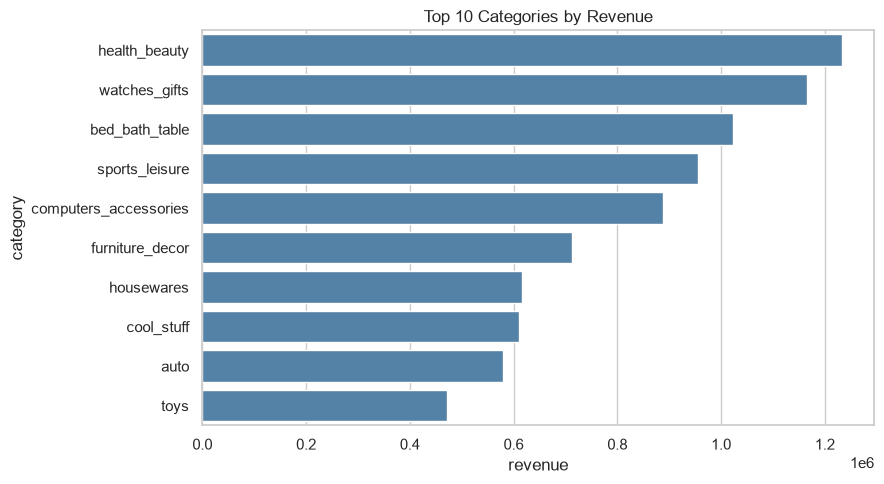

In [8]:
cats = pd.read_sql("""
    SELECT COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category,
           SUM(v.price)::float AS revenue
    FROM vw_delivered_items v
    JOIN products p ON p.product_id = v.product_id
    LEFT JOIN category_translation t ON t.product_category_name = p.product_category_name
    GROUP BY 1 ORDER BY revenue DESC LIMIT 10
""", engine)

plt.figure(figsize=(9, 5))
sns.barplot(data=cats, y="category", x="revenue", color="steelblue")
plt.title("Top 10 Categories by Revenue")
plt.tight_layout()
plt.savefig("images/top_categories.png", dpi=150)
plt.show()

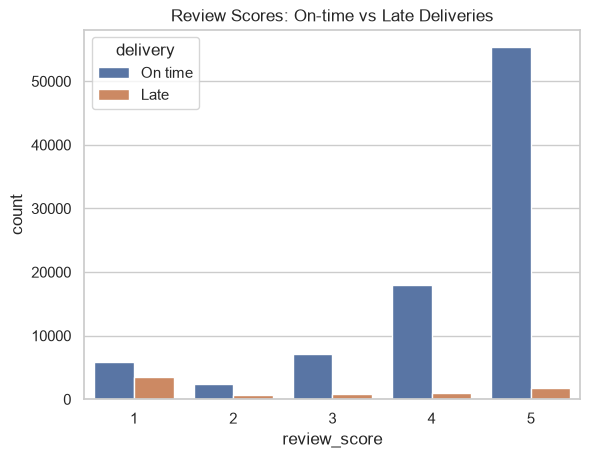

In [9]:
rev = pd.read_sql("""
    SELECT (o.order_delivered_customer_date > o.order_estimated_delivery_date) AS is_late,
           r.review_score
    FROM orders o JOIN order_reviews r USING (order_id)
    WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
""", engine)
rev["delivery"] = rev["is_late"].map({True: "Late", False: "On time"})

sns.countplot(data=rev, x="review_score", hue="delivery")
plt.title("Review Scores: On-time vs Late Deliveries")
plt.savefig("images/reviews_vs_delivery.png", dpi=150)
plt.show()

In [10]:
rfm = pd.read_sql("""
    SELECT customer_unique_id,
           MAX(order_purchase_timestamp) AS last_order,
           COUNT(DISTINCT order_id)      AS frequency,
           SUM(price)::float             AS monetary
    FROM vw_delivered_items
    GROUP BY customer_unique_id
""", engine, parse_dates=["last_order"])

snapshot = rfm["last_order"].max() + pd.Timedelta(days=1)
rfm["recency"] = (snapshot - rfm["last_order"]).dt.days

# R and M: quartile scores (rank first to avoid duplicate-edge errors)
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

# F: almost everyone has 1 order, so quartiles would be meaningless. Use fixed bins.
rfm["F"] = np.select([rfm["frequency"] == 1, rfm["frequency"] == 2], [1, 2], default=3)

def segment(row):
    if row.F >= 2 and row.R >= 3:
        return "Champions"
    if row.F >= 2:
        return "Loyal / Repeat"
    if row.R >= 3 and row.M >= 3:
        return "High-Value New"
    if row.R >= 3:
        return "New / Recent"
    if row.M >= 3:
        return "At Risk (High Spenders)"
    return "Lost / Low Value"

rfm["segment"] = rfm.apply(segment, axis=1)

summary = (rfm.groupby("segment")
              .agg(customers=("customer_unique_id", "count"),
                   revenue=("monetary", "sum"),
                   avg_spend=("monetary", "mean"))
              .sort_values("revenue", ascending=False)
              .round(1))
summary["revenue_share_pct"] = (100 * summary["revenue"] / summary["revenue"].sum()).round(1)
summary

,customers,revenue,avg_spend,revenue_share_pct
segment,,,,
High-Value New,22292,5163841.9,231.6,39.1
At Risk (High Spenders),22044,5151392.2,233.7,39.0
Lost / Low Value,23377,1103998.7,47.2,8.4
New / Recent,22844,1073856.5,47.0,8.1
Champions,1543,407783.6,264.3,3.1
Loyal / Repeat,1258,320625.2,254.9,2.4


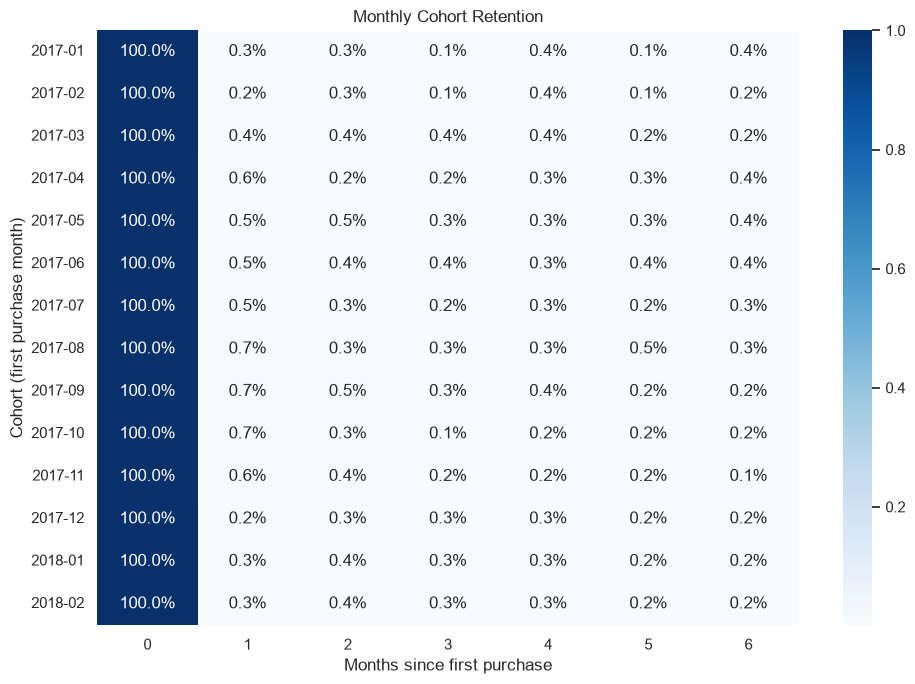

In [11]:
orders = pd.read_sql("""
    SELECT DISTINCT customer_unique_id, order_id, order_month
    FROM vw_delivered_items
""", engine, parse_dates=["order_month"])

orders["cohort_month"] = orders.groupby("customer_unique_id")["order_month"].transform("min")
orders["month_index"] = ((orders["order_month"].dt.year - orders["cohort_month"].dt.year) * 12
                         + (orders["order_month"].dt.month - orders["cohort_month"].dt.month))

cohort = (orders.groupby(["cohort_month", "month_index"])["customer_unique_id"]
                .nunique().unstack(fill_value=0))
retention = cohort.div(cohort[0], axis=0)

# Keep 2017-01 to 2018-02 cohorts and the first 7 months (0 to 6)
retention = retention.loc["2017-01":"2018-02", 0:6]
retention.index = retention.index.strftime("%Y-%m")

plt.figure(figsize=(10, 7))
sns.heatmap(retention, annot=True, fmt=".1%", cmap="Blues")
plt.title("Monthly Cohort Retention")
plt.ylabel("Cohort (first purchase month)")
plt.xlabel("Months since first purchase")
plt.tight_layout()
plt.savefig("images/cohort_retention.png", dpi=150)
plt.show()